# CTA El Initial Stop and Ridership Analysis

See [README-cta-el.md](./README-cta-el.md) for information on the data sorces amd how the database was populated. This uses [JupySQL](https://ploomber.io/blog/jupysql/) to connect this notebook to the SQLite database. In hindsight, DuckDB may have been a better choice than SQLite as DuckDB is designed for OLAP.

    

## Setup

In [35]:
%load_ext sql

The sql extension is already loaded. To reload it, use:
  %reload_ext sql


In [36]:
from sqlalchemy import create_engine

In [37]:
engine = create_engine("sqlite:///cta-l.db")

In [38]:
%sql engine

In [39]:
%config SqlMagic.displaylimit = 50;

In [40]:
%%sql
SELECT
  COUNT(*)
FROM
  stops;

Running query in 'sqlite:///cta-l.db'

COUNT(*)
300


In [41]:
%%sql
SELECT
  COUNT(*)
FROM
  daily_ridership;

Running query in 'sqlite:///cta-l.db'

COUNT(*)
1210794


## Stops

In this data set, a stop can be thought of as a platofrm in a staton. Here are the stations having more than two stops. Normally stops just go in two directions.

In [42]:
%%sql
SELECT
  name AS stop_name,
  station_descriptive_name,
  direction,
  red,
  blue,
  green,
  brown,
  purple,
  purple_express,
  yellow,
  pink,
  orange
FROM
  stops
WHERE
  map_id IN (
    SELECT
      map_id
    FROM
      stops
    GROUP BY
      map_id
    HAVING
      COUNT(*) > 2
  )
ORDER BY
  name DESC;

Running query in 'sqlite:///cta-l.db'

stop_name,station_descriptive_name,direction,red,blue,green,brown,purple,purple_express,yellow,pink,orange
Wilson (Loop-bound),Wilson (Red & Purple lines),S,0,0,0,0,0,1,0,0,0
Wilson (Linden-bound),Wilson (Red & Purple lines),N,0,0,0,0,0,1,0,0,0
Wilson (Howard-bound),Wilson (Red & Purple lines),N,1,0,0,0,0,0,0,0,0
Wilson (95th-bound),Wilson (Red & Purple lines),S,1,0,0,0,0,0,0,0,0
Sheridan (Loop-bound),Sheridan (Red Line),S,0,0,0,0,0,0,0,0,0
Sheridan (Howard-bound),Sheridan (Red Line),N,1,0,0,0,0,0,0,0,0
Sheridan (Howard-Linden-bound),Sheridan (Red Line),N,0,0,0,0,0,0,0,0,0
Sheridan (95th-bound),Sheridan (Red Line),S,1,0,0,0,0,0,0,0,0
Roosevelt (Midway-63rd-bound),"Roosevelt (Red, Orange & Green lines)",S,0,0,1,0,0,0,0,0,1
Roosevelt (Loop-Harlem-bound),"Roosevelt (Red, Orange & Green lines)",N,0,0,1,0,0,0,0,0,1


## Stations

Stations with the maximum number of lines:

In [43]:
%%sql
SELECT
  name,
  red + blue + green + brown + purple + purple_express + yellow + pink + orange AS "number of lines"
FROM
  stations
ORDER BY
  "number of lines" desc,
  name asc
LIMIT
  10;

Running query in 'sqlite:///cta-l.db'

name,number of lines
Clark/Lake,6
Adams/Wabash,5
State/Lake,5
Washington/Wabash,5
Harold Washington Library-State/Van Buren,4
Howard,4
LaSalle/Van Buren,4
Quincy/Wells,4
Washington/Wells,4
Belmont,3


## Ridership

Date range of this dataset:

In [44]:
%%sql
SELECT
  MIN(DATE),
  MAX(DATE)
FROM
  daily_ridership;

Running query in 'sqlite:///cta-l.db'

MIN(DATE),MAX(DATE)
2001-01-01,2024-03-31


In [45]:
%%sql
SELECT
  SUM(rides) / 1000000 AS 'rides in millions',
  STRFTIME ('%Y', DATE) AS YEAR
FROM
  daily_ridership
GROUP BY
  STRFTIME ('%Y', DATE)
ORDER BY
  STRFTIME ('%Y', DATE)

Running query in 'sqlite:///cta-l.db'

rides in millions,YEAR
151,2001
152,2002
150,2003
148,2004
154,2005
161,2006
157,2007
165,2008
167,2009
173,2010


Top twenty stops with the highest overall ridership:

In [46]:
%%sql
WITH
  total_daily_rides_per_stop AS (
    SELECT
      map_id,
      SUM(rides) / 1000000.0 AS rides_in_millions
    FROM
      daily_ridership
    GROUP BY
      map_id
  )
SELECT
  name,
  total_daily_rides_per_stop.rides_in_millions
FROM
  stations
  JOIN total_daily_rides_per_stop ON stations.map_id = total_daily_rides_per_stop.map_id
ORDER BY
  total_daily_rides_per_stop.rides_in_millions DESC
LIMIT
  20;

Running query in 'sqlite:///cta-l.db'

name,rides_in_millions
Lake,108.118545
Clark/Lake,106.24997
Chicago,97.779502
Belmont,79.921156
Fullerton,78.718192
95th/Dan Ryan,77.923066
Grand,73.351992
O'Hare,73.056608
Roosevelt,67.108929
Jackson,64.742024


Rides in January of 2024.

In [106]:
import matplotlib.pyplot as plt
import pandas as pd

In [124]:
%%sql daily_rides << 
SELECT
  DATE,
  SUM(rides) AS daily_rides
FROM
  daily_ridership
WHERE
  DATE BETWEEN "2024-01-01" AND "2025-01-31"
GROUP BY
  DATE



Running query in 'sqlite:///cta-l.db'

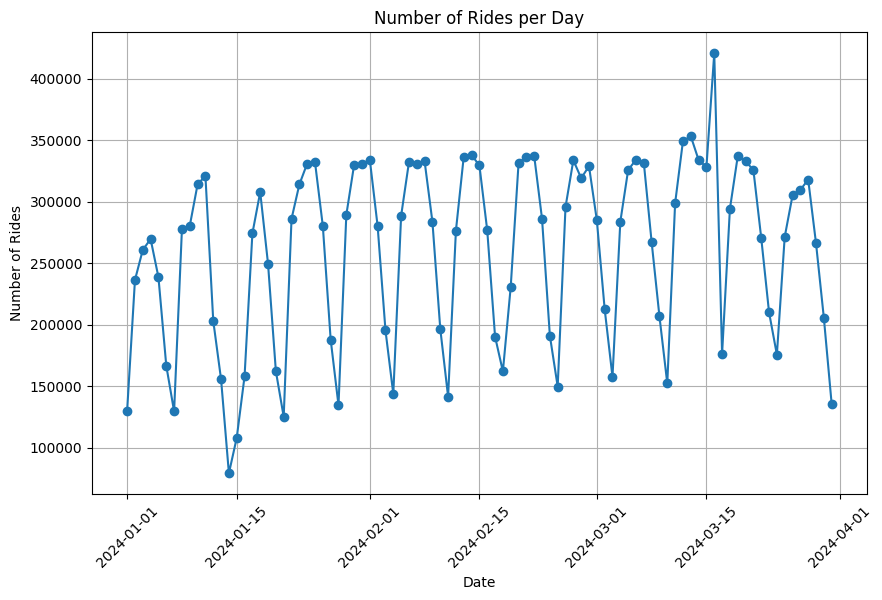

In [125]:
rides_data = daily_rides.DataFrame()

# Ensure date column is in datetime format
rides_data['date'] = pd.to_datetime(rides_data['date'])

# Plotting
plt.figure(figsize=(10, 6))
plt.plot(rides_data['date'], rides_data['daily_rides'], marker='o')
plt.title('Number of Rides per Day')
plt.xlabel('Date')
plt.ylabel('Number of Rides')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

# Further Reading
1. [GDAL + geopandas app](https://github.com/ploomber/doc/tree/main/examples/voila/gdala)